# GASMAS Signal Simulation

Each detected photon $i$ carries three partial path lengths from MCX:
$L_{\mathrm{air},i}$, $L_{\mathrm{cw},i}$, $L_{\mathrm{lung},i}$.
Its survival weight at wavelength $\lambda$ is

$$
w_i(\lambda) =
\exp\!\bigl[-\alpha_{\mathrm{air}}(\lambda)\,L_{\mathrm{air},i}\bigr]
\cdot
\exp\!\bigl[-\mu_{\mathrm{cw}}\,L_{\mathrm{cw},i}
             - \mu_{\mathrm{lung}}\,L_{\mathrm{lung},i}\bigr]
$$

Summing over all detected photons gives the detector signal

$$
S(\lambda) = \sum_{i} w_i(\lambda)
$$

Normalising to the off-peak baseline $S_0 = \max_\lambda S(\lambda)$ gives

$$
S_\mathrm{rel}(\lambda) = \frac{S(\lambda)}{S_0}, \qquad
$$

## Pipeline

1. Load O$_2$ A-band absorption cross-section from HITRAN
2. Set tissue optical properties (chest wall, lung)
3. Compute per-photon transmittance $w_i(\lambda)$ on GPU
4. Sum over photons → $S(\lambda)$
5. Normalise → $S_\mathrm{rel}(\lambda)$, extract $S_\mathrm{rel,peak}$

##GPU & environment check

In [18]:
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')
if device.type == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('WARNING: running on CPU — much slower. Set Runtime → GPU → T4.')


Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB


In [19]:
import warnings
from pyparsing import PyparsingDeprecationWarning

# Suppress specific PyparsingDeprecationWarning that comes from matplotlib/pyparsing interaction
warnings.filterwarnings("ignore", category=FutureWarning, module='matplotlib')
warnings.filterwarnings("ignore", category=DeprecationWarning, module='pyparsing')
warnings.filterwarnings("ignore", category=PyparsingDeprecationWarning, module='matplotlib')
warnings.filterwarnings("ignore", category=SyntaxWarning)

print('Warnings configured.')

Warnings configured.


##Mount Drive & install deps

In [20]:
from google.colab import drive
drive.mount('/content/drive')
%pip install -q hitran-api matplotlib numpy scipy


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


##Parameters

In [21]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import hapi
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Geometry / simulation setup
VTX_SIZE_MM    = 0.1                              # voxel size [mm]
SDS_LIST_MM    = [5, 10, 15, 20, 25, 30, 35]      # detector positions [mm]
CW_THICKNESSES = [10, 15, 20, 25, 30, 35]         # chest-wall thicknesses [mm]
DATA_ROOT      = '/content/drive/MyDrive/GASMAS_Corrected/External'

# Spectroscopy
LAMBDA_CENTER_NM = 763.84251     # O2 A-band peak (R7R7 line)
SCAN_HALF_NM     = 0.025         # ±scan window [nm] — covers full Voigt wings
X_O2             = 0.21          # O2 mole fraction in air
P_ATM            = 1.0           # pressure [atm]
T_KELVIN         = 296.0         # temperature [K]

# Tissue optical properties at 763 nm (wavelength-independent over scan)
MU_LUNG_MM   = 0.0100            # mm⁻¹  effective attenuation
MU_THORAX_MM = 0.0100            # mm⁻¹  effective attenuation

# GPU batching
BATCH_SIZE = 50_000

#MCX run config
N_LAUNCHED_PER_RUN = 10_000_000

# Plotting helpers
CW_LABELS = [f'{t}mm' for t in CW_THICKNESSES]
CMAP      = plt.cm.viridis
CW_COLORS = {f'{t}mm': CMAP(i / max(1, len(CW_THICKNESSES)-1))
             for i, t in enumerate(CW_THICKNESSES)}

print('Parameters set.')
print(f'  CW thicknesses : {CW_THICKNESSES} mm')
print(f'  Detectors (SDS): {SDS_LIST_MM} mm')
print(f'  Scan window    : {LAMBDA_CENTER_NM-SCAN_HALF_NM:.4f}–{LAMBDA_CENTER_NM+SCAN_HALF_NM:.4f} nm')
print(f'  μ_thorax, μ_lung: {MU_THORAX_MM}, {MU_LUNG_MM} mm⁻¹')
print(f'  Batch size     : {BATCH_SIZE:,} photons')


Parameters set.
  CW thicknesses : [10, 15, 20, 25, 30, 35] mm
  Detectors (SDS): [5, 10, 15, 20, 25, 30, 35] mm
  Scan window    : 763.8175–763.8675 nm
  μ_thorax, μ_lung: 0.01, 0.01 mm⁻¹
  Batch size     : 50,000 photons


##A-band absorption coefficient

Using ./hapi_data

O2_Aband
                     Lines parsed: 3

Data is fetched from http://hitran.org

BEGIN DOWNLOAD: O2_Aband
  65536 bytes written to ./hapi_data/O2_Aband.data
Header written to ./hapi_data/O2_Aband.header
END DOWNLOAD
                     Lines parsed: 3
PROCESSED
{'air': 1.0}
0.004031 seconds elapsed for abscoef; nlines = 3
Spectral grid : 8570 points
Range         : 763.81751 – 763.86751 nm
Peak α        : 2.601155e-05 mm⁻¹  at 763.84251 nm


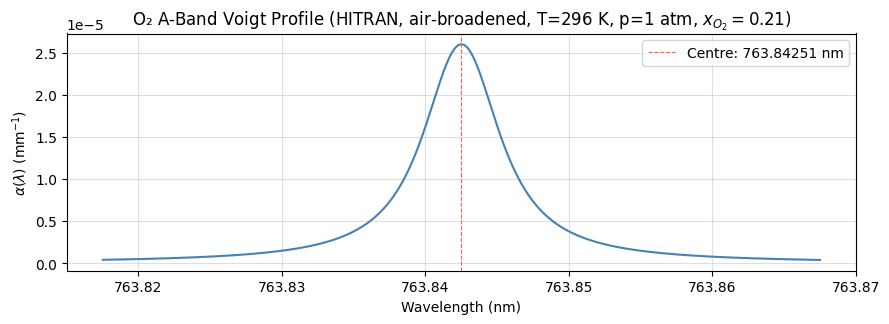

In [22]:

lambda_min_nm = LAMBDA_CENTER_NM - SCAN_HALF_NM
lambda_max_nm = LAMBDA_CENTER_NM + SCAN_HALF_NM
nu_min  = 1e7 / lambda_max_nm
nu_max  = 1e7 / lambda_min_nm
NU_STEP = 0.0001    # cm⁻¹

HAPI_DIR = './hapi_data'
os.makedirs(HAPI_DIR, exist_ok=True)
hapi.db_begin(HAPI_DIR)
hapi.fetch('O2_Aband', 7, 1, nu_min - 2.0, nu_max + 2.0)

nu_out, alpha_cm = hapi.absorptionCoefficient_Voigt(
    SourceTables    = 'O2_Aband',
    Diluent         = {'air': 1.0},
    Environment     = {'p': P_ATM, 'T': T_KELVIN},
    HITRAN_units    = False,
    WavenumberRange = [nu_min, nu_max],
    WavenumberStep  = NU_STEP,
    WavenumberWing  = 50,
)

# Convert: cm⁻¹ → mm⁻¹, multiply by O₂ mole fraction (assumes ambient air column)
alpha_nu_mm = np.array(alpha_cm) * 0.1 * X_O2
lambda_nm   = 1e7 / np.array(nu_out)
idx         = np.argsort(lambda_nm)
lambda_nm, alpha_nu_mm = lambda_nm[idx], alpha_nu_mm[idx]

alpha_interp  = interp1d(lambda_nm, alpha_nu_mm, kind='linear',
                         fill_value=0.0, bounds_error=False)
ALPHA_PEAK_MM = float(np.max(alpha_nu_mm))

print(f'Spectral grid : {len(lambda_nm)} points')
print(f'Range         : {lambda_nm[0]:.5f} – {lambda_nm[-1]:.5f} nm')
print(f'Peak α        : {ALPHA_PEAK_MM:.6e} mm⁻¹  at {lambda_nm[np.argmax(alpha_nu_mm)]:.5f} nm')

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(lambda_nm, alpha_nu_mm, color='steelblue', lw=1.5)
ax.axvline(LAMBDA_CENTER_NM, color='tomato', ls='--', lw=0.8,
           label=f'Centre: {LAMBDA_CENTER_NM:.5f} nm')
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel(r'$\alpha(\lambda)$ (mm$^{-1}$)')
ax.set_title('O₂ A-Band Voigt Profile (HITRAN, air-broadened, T=296 K, p=1 atm, $x_{O_2}=0.21$)')
ax.ticklabel_format(useOffset=False, style='plain', axis='x')
ax.legend(); ax.grid(True, alpha=0.4)
plt.tight_layout(); plt.show()


##Core GPU per-photon transmittance function

In [23]:

def perphoton_sum_gpu(L_air_all, L_thorax_all, L_lung_all,
                      alpha, mu_thorax=MU_THORAX_MM, mu_lung=MU_LUNG_MM,
                      batch_size=BATCH_SIZE, dev=device):

    alpha_gpu = torch.tensor(alpha, dtype=torch.float64, device=dev)
    N = len(L_air_all)
    if N == 0:
        return np.zeros(len(alpha), dtype=np.float64)
    S_sum = torch.zeros(len(alpha), dtype=torch.float64, device=dev)

    for start in range(0, N, batch_size):
        sl = slice(start, start + batch_size)
        L_air    = torch.tensor(L_air_all[sl],    dtype=torch.float64, device=dev)
        L_thorax = torch.tensor(L_thorax_all[sl], dtype=torch.float64, device=dev)
        L_lung   = torch.tensor(L_lung_all[sl],   dtype=torch.float64, device=dev)

        # Wavelength-independent tissue weight per photon
        w = torch.exp(-mu_thorax * L_thorax - mu_lung * L_lung)         # (B,)

        # Wavelength-dependent air-absorption term
        air_exp = torch.exp(-L_air.unsqueeze(1) * alpha_gpu.unsqueeze(0))  # (B, n_lambda)

        S_sum += (w.unsqueeze(1) * air_exp).sum(dim=0)

    return S_sum.cpu().numpy().astype(np.float64)


def extract_gasmas_observables(spectrum, alpha_peak):
    """

    Returns dict with:
        y0       : baseline (off-peak max)
        y_min    : minimum (on-peak)
        d_abs    : y0 - y_min (absolute dip)
        d_frac   : d_abs / y0 (fractional GASMAS signal)
        A        : -ln(y/y0)  (absorbance spectrum)
        A_peak   : max(A)
        L_eq     : A_peak / alpha_peak    [mm]
    """
    y0    = float(np.max(spectrum))
    y_min = float(np.min(spectrum))
    if y0 <= 0:
        return dict(y0=0.0, y_min=0.0, d_abs=0.0, d_frac=0.0,
                    A=np.zeros_like(spectrum), A_peak=0.0, L_eq=0.0)
    d_abs  = y0 - y_min
    d_frac = d_abs / y0
    A = -np.log(np.clip(spectrum / y0, 1e-300, None))
    A_peak = float(np.max(A))
    L_eq   = A_peak / alpha_peak if alpha_peak > 0 else 0.0
    return dict(y0=y0, y_min=y_min, d_abs=d_abs, d_frac=d_frac,
                A=A, A_peak=A_peak, L_eq=L_eq)

print('Core functions defined.')


Core functions defined.


##load MCX data & compute GASMAS signal

In [24]:
results = {}     # results[cw_label][det_id] = dict of arrays/scalars


for t in CW_THICKNESSES:
    cw   = f'{t}mm'
    path = f'{DATA_ROOT}/gasmas_simulation_results_{t}mm.npz'
    with np.load(path) as d:
        detp = d['detp'].copy()                  # (4, N_detected)

    print(f'\n── CW = {cw}  ({detp.shape[1]:,} photons total) ──')
    results[cw] = {}

    for det_id in sorted(np.unique(detp[0].astype(int))):
        ph = detp[:, detp[0].astype(int) == det_id]    # photons for this detector
        #n_total = ph.shape[1]
        n_total = 1e7
        if n_total == 0:
            continue

        # Convert step counts → physical path lengths [mm]
        L_lung_all   = ph[1] * VTX_SIZE_MM
        L_air_all    = ph[2] * VTX_SIZE_MM
        L_thorax_all = ph[3] * VTX_SIZE_MM

        n_air    = int(np.sum(ph[2] > 0))               # photons that hit air at all
        f_air    = n_air / n_total
        Lair_mean_signal = float(np.mean(L_air_all[L_air_all > 0])) if n_air > 0 else 0.0

        # ── Compute raw oscilloscope-like sum S(λ) (no division) ───────────
        S = perphoton_sum_gpu(L_air_all, L_thorax_all, L_lung_all, alpha_nu_mm)

        # ── Derived normalisations ──────────────────────────────────────────
        T = S / n_total                                       # per-photon [0,1]
        if N_LAUNCHED_PER_RUN is not None and N_LAUNCHED_PER_RUN > 0:
            T_geom = S / N_LAUNCHED_PER_RUN                   # true channel transmittance
        else:
            T_geom = None

        # ── Extract GASMAS observables (uses S — identical result for T, T_geom) ──
        obs = extract_gasmas_observables(S, ALPHA_PEAK_MM)

        # Convenience scalars in each normalisation (all related by constants)
        S0      = obs['y0']
        T0      = S0 / n_total
        T0_geom = S0 / N_LAUNCHED_PER_RUN if T_geom is not None else None
        dS_abs  = obs['d_abs']
        dT_abs  = dS_abs / n_total
        dT_abs_geom = dS_abs / N_LAUNCHED_PER_RUN if T_geom is not None else None

        results[cw][det_id] = {
            'sds'              : SDS_LIST_MM[det_id - 1],
            'n_total'          : n_total,
            'n_air'            : n_air,
            'f_air'            : f_air,
            'n_launched'       : N_LAUNCHED_PER_RUN,
            'Lair_mean_signal' : Lair_mean_signal,
            # Three flavours of the spectrum
            'S'                : S,
            'T'                : T,
            'T_geom'           : T_geom,
            # Baselines
            'S0'               : S0,
            'T0'               : T0,
            'T0_geom'          : T0_geom,
            # Absolute dips
            'dS_abs'           : dS_abs,
            'dT_abs'           : dT_abs,
            'dT_abs_geom'      : dT_abs_geom,
            # GASMAS observables (normalisation-invariant)
            'd_frac'           : obs['d_frac'],   # ≡ ΔS/S0 = ΔT/T0 = ΔT_geom/T0_geom
            'A'                : obs['A'],
            'A_peak'           : obs['A_peak'],
            'L_eq'             : obs['L_eq'],
        }

        print(f'  det {det_id:2d}  SDS={SDS_LIST_MM[det_id-1]:2d}mm  '
              f'N_det={n_total:7,}  f_air={f_air*100:5.1f}%  '
              f'S₀={S0:.3e}  T₀={T0:.3e}  '
              + (f'T₀_geom={T0_geom:.3e}  ' if T0_geom is not None else '')
              + f'ΔS/S₀={obs["d_frac"]:.3e}  L_eq={obs["L_eq"]:6.2f}mm')

print('\nAll detectors processed.')



── CW = 10mm  (504,031 photons total) ──
  det  1  SDS= 5mm  N_det=10,000,000.0  f_air=  0.2%  S₀=3.312e+05  T₀=3.312e-02  T₀_geom=3.312e-02  ΔS/S₀=6.808e-06  L_eq=  0.26mm
  det  2  SDS=10mm  N_det=10,000,000.0  f_air=  0.1%  S₀=2.691e+04  T₀=2.691e-03  T₀_geom=2.691e-03  ΔS/S₀=6.291e-05  L_eq=  2.42mm
  det  3  SDS=15mm  N_det=10,000,000.0  f_air=  0.1%  S₀=4.829e+03  T₀=4.829e-04  T₀_geom=4.829e-04  ΔS/S₀=2.328e-04  L_eq=  8.95mm
  det  4  SDS=20mm  N_det=10,000,000.0  f_air=  0.0%  S₀=1.166e+03  T₀=1.166e-04  T₀_geom=1.166e-04  ΔS/S₀=5.697e-04  L_eq= 21.91mm
  det  5  SDS=25mm  N_det=10,000,000.0  f_air=  0.0%  S₀=3.542e+02  T₀=3.542e-05  T₀_geom=3.542e-05  ΔS/S₀=1.138e-03  L_eq= 43.78mm
  det  6  SDS=30mm  N_det=10,000,000.0  f_air=  0.0%  S₀=1.176e+02  T₀=1.176e-05  T₀_geom=1.176e-05  ΔS/S₀=1.857e-03  L_eq= 71.45mm
  det  7  SDS=35mm  N_det=10,000,000.0  f_air=  0.0%  S₀=3.929e+01  T₀=3.929e-06  T₀_geom=3.929e-06  ΔS/S₀=2.850e-03  L_eq=109.72mm

── CW = 15mm  (497,892 photons to

##Oscilloscope view

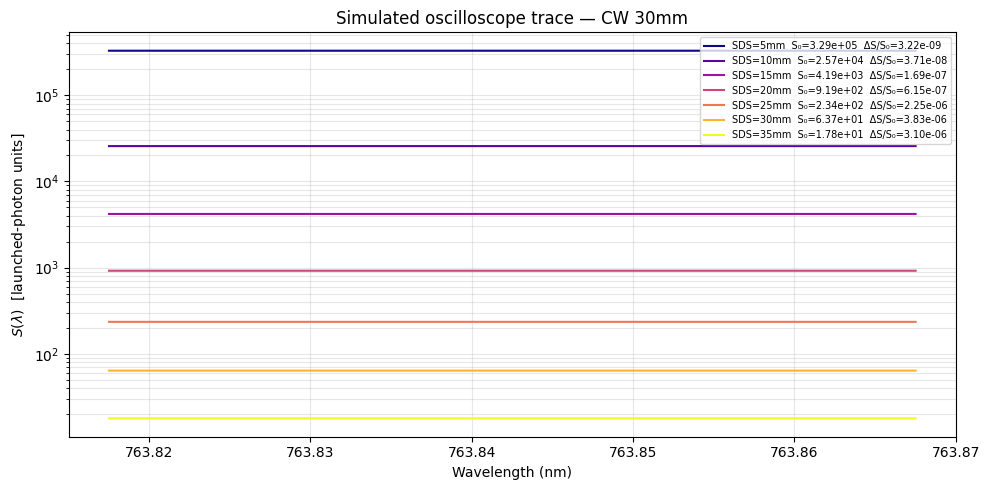

In [25]:

CW_TO_PLOT = '30mm'   # ← change as desired
if CW_TO_PLOT not in results:
    raise KeyError(f'{CW_TO_PLOT} not in results. Available: {list(results.keys())}')

det_ids  = sorted(results[CW_TO_PLOT].keys())
cmap_sds = plt.cm.plasma

fig, ax = plt.subplots(figsize=(10, 5))
for k, det_id in enumerate(det_ids):
    r = results[CW_TO_PLOT][det_id]
    ax.plot(lambda_nm, r['S'], color=cmap_sds(k / max(1, len(det_ids)-1)),
            lw=1.5,
            label=f"SDS={r['sds']}mm  S₀={r['S0']:.2e}  ΔS/S₀={r['d_frac']:.2e}")
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel(r'$S(\lambda)$  [launched-photon units]')
ax.set_title(f'Simulated oscilloscope trace — CW {CW_TO_PLOT}')
ax.set_yscale('log')
ax.ticklabel_format(useOffset=False, style='plain', axis='x')
ax.legend(fontsize=7, ncol=1); ax.grid(True, which='both', alpha=0.3)
plt.tight_layout(); plt.show()


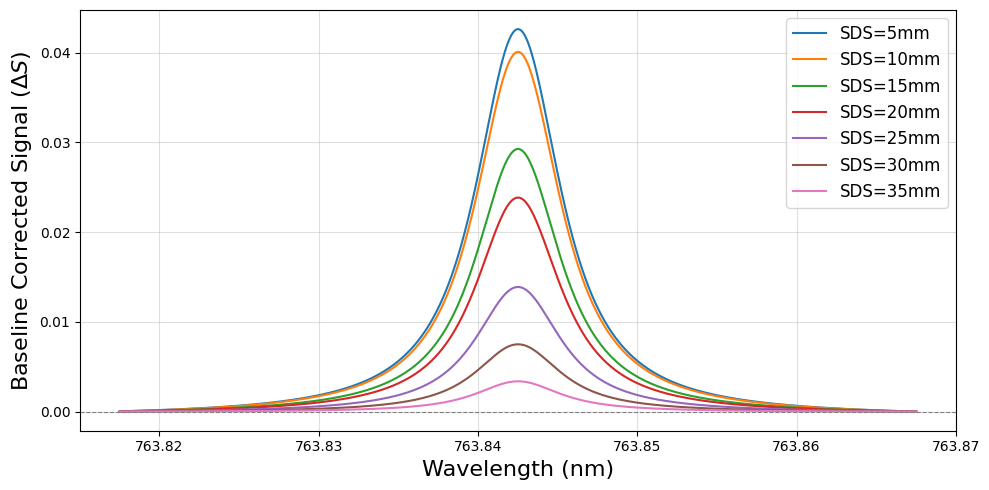

In [26]:
CW_TO_PLOT = '20mm'  # Change as desired

if CW_TO_PLOT not in results:
    raise KeyError(f'{CW_TO_PLOT} not in results. Available: {list(results.keys())}')

det_ids = sorted(results[CW_TO_PLOT].keys())
cmap_sds = plt.cm.plasma

fig, ax = plt.subplots(figsize=(10, 5))
for k, det_id in enumerate(det_ids):
    r = results[CW_TO_PLOT][det_id]
    ax.plot(lambda_nm, r['S0'] - r['S'],
            lw=1.5,
            label=f"SDS={r['sds']}mm")

ax.axhline(0, color='grey', ls='--', lw=0.8)
ax.set_xlabel('Wavelength (nm)',fontsize=16)
ax.set_ylabel('Baseline Corrected Signal ($\Delta S$)',fontsize=16)
#ax.set_title(f'Simulated S(λ) - S₀ — CW {CW_TO_PLOT}')
ax.ticklabel_format(useOffset=False, style='plain', axis='x')
ax.legend(fontsize=12); ax.grid(True, alpha=0.4)
plt.tight_layout(); plt.show()

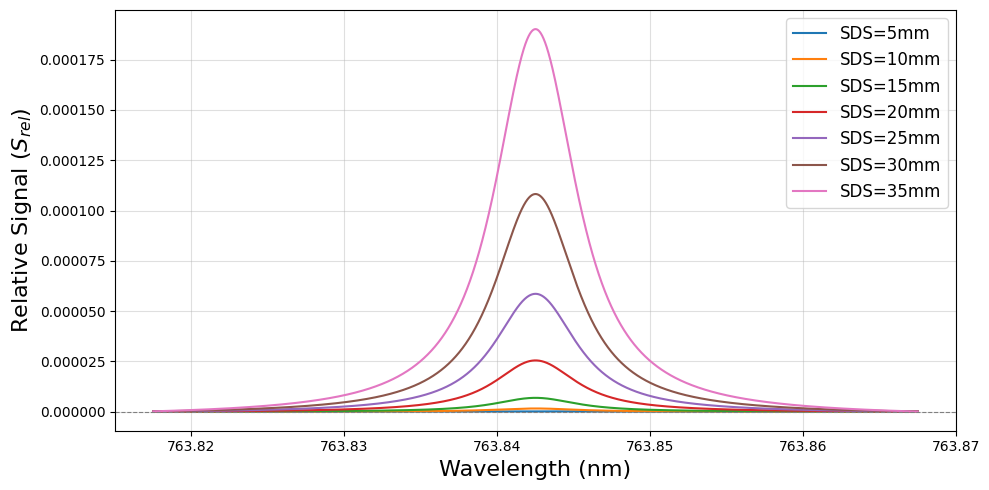

In [27]:
CW_TO_PLOT = '20mm'  # Change as desired

if CW_TO_PLOT not in results:
    raise KeyError(f'{CW_TO_PLOT} not in results. Available: {list(results.keys())}')

det_ids = sorted(results[CW_TO_PLOT].keys())
cmap_sds = plt.cm.plasma

fig, ax = plt.subplots(figsize=(10, 5))
for k, det_id in enumerate(det_ids):
    r = results[CW_TO_PLOT][det_id]
    # Calculate (S - S0) / S0. Add a small epsilon to S0 to avoid division by zero
    # if S0 happens to be exactly zero, although this should not occur with real data.
    s0_val = r['S0']
    if s0_val == 0:
        # Handle cases where S0 might be zero to prevent division by zero errors
        plot_data = np.zeros_like(r['S'])
    else:
        plot_data = -(r['S'] - s0_val) / s0_val

    ax.plot(lambda_nm, plot_data,
            lw=1.5,
            label=f"SDS={r['sds']}mm")

ax.axhline(0, color='grey', ls='--', lw=0.8)
ax.set_xlabel('Wavelength (nm)',fontsize=16)
ax.set_ylabel('Relative Signal ($S_{rel}$)',fontsize=16)
#ax.set_title(f'Simulated $(S(\lambda) - S_0) / S_0$ — CW {CW_TO_PLOT}')
ax.ticklabel_format(useOffset=False, style='plain', axis='x')
ax.legend(fontsize=12); ax.grid(True, alpha=0.4)
plt.tight_layout(); plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

for cw in sorted(results.keys(), key=lambda s: int(s[:-2])):
    det_sorted = sorted(results[cw].keys())
    sds_values = []
    snr_experimental_values = []

    for det_id in det_sorted:
        r = results[cw][det_id]
        # Experimental SNR: ((S - S0) / S0) * sqrt(N_detector)
        # r['d_frac'] is already (S - S0) / S0 or (S0 - S_min) / S0, which is the fractional signal
        # N_detector is r['n_total']
        if r['n_total'] > 0:
            snr_experimental = r['d_frac'] * np.sqrt(r['n_total'])
        else:
            snr_experimental = 0.0 # Handle cases with no detected photons

        sds_values.append(r['sds'])
        snr_experimental_values.append(snr_experimental)

    c = CW_COLORS[cw]
    ax.semilogy(sds_values, snr_experimental_values, 'o-', color=c, lw=2, label=cw)

ax.set_xlabel('SDS (mm)')
ax.set_ylabel(r'Experimental SNR: $(\Delta S / S_0) \cdot \sqrt{N_{\mathrm{det}}}$')
ax.set_title('Experimental SNR vs SDS for various CW thicknesses')
ax.legend(fontsize=10, title='CW Thickness')
ax.grid(True, which='both', alpha=0.4)
plt.tight_layout()
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

for cw in sorted(results.keys(), key=lambda s: int(s[:-2])):
    det_sorted = sorted(results[cw].keys())
    sds_values = []
    d_frac_values = []

    for det_id in det_sorted:
        r = results[cw][det_id]
        # The fractional GASMAS signal (S - S0) / S0 is stored as 'd_frac'
        d_frac_values.append(r['dS_abs'])
        sds_values.append(r['sds'])

    c = CW_COLORS[cw]
    ax.semilogy(sds_values, d_frac_values, 'o-', lw=2, label=cw)

ax.set_xlabel('SDS (mm)',fontsize=16)
ax.set_ylabel(r'$\Delta S^{peak}$',fontsize=16)
#ax.set_title(r'$(S - S_0) / S_0$ vs SDS for various CW thicknesses')
ax.legend(fontsize=10, title='CW Thickness')
ax.grid(True, which='both', alpha=0.4)
plt.tight_layout()
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

for cw in sorted(results.keys(), key=lambda s: int(s[:-2])):
    det_sorted = sorted(results[cw].keys())
    sds_values = []
    d_frac_values = []

    for det_id in det_sorted:
        r = results[cw][det_id]
        # The fractional GASMAS signal (S - S0) / S0 is stored as 'd_frac'
        d_frac_values.append(r['d_frac'])
        sds_values.append(r['sds'])

    c = CW_COLORS[cw]
    ax.semilogy(sds_values, d_frac_values, 'o-', lw=2, label=cw)

ax.set_xlabel('SDS (mm)',fontsize=16)
ax.set_ylabel(r'$S_{rel}^{peak}$',fontsize=16)
#ax.set_title(r'$(S - S_0) / S_0$ vs SDS for various CW thicknesses')
ax.legend(fontsize=10, title='CW Thickness')
ax.grid(True, which='both', alpha=0.4)
plt.tight_layout()
plt.show()